In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py
import codecs

import EIANN.utils as ut
import EIANN.plot as pt

from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/utils/data_utils.py:6: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


### Load pre-trained EIANN (DTP with weight symmetry)

In [5]:
network_name = "20231129_EIANN_2_hidden_mnist_van_bp_relu_SGD_config_G_complete_optimized"
network_seed = 66049
data_seed = 257
saved_network_path = root_dir + f"/EIANN/data/saved_network_pickles/mnist/{network_name}_{network_seed}_{data_seed}.pkl"
network = ut.load_network(saved_network_path)

Loading network from '/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/data/saved_network_pickles/mnist/20231129_EIANN_2_hidden_mnist_van_bp_relu_SGD_config_G_complete_optimized_66049_257.pkl'
Network successfully loaded from '/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/data/saved_network_pickles/mnist/20231129_EIANN_2_hidden_mnist_van_bp_relu_SGD_config_G_complete_optimized_66049_257.pkl'


In [12]:
from tqdm import tqdm
accuracy_list = []

for noise_std in tqdm(np.arange(0, 1, 0.1)):
    train_dataloader, val_dataloader, test_dataloader, data_generator = ut.get_MNIST_dataloaders_with_noise(batch_size='full_dataset', data_dir=None, mean=0.0, std=noise_std)
    pop_activity_dict, pattern_labels = ut.compute_raw_test_activity(network, test_dataloader)
    output_activity = pop_activity_dict[network.output_pop.fullname].clone()
    percent_correct = ut.compute_test_accuracy(output_activity, pattern_labels)
    accuracy_list.append(percent_correct)

100%|██████████| 10/10 [01:30<00:00,  9.09s/it]


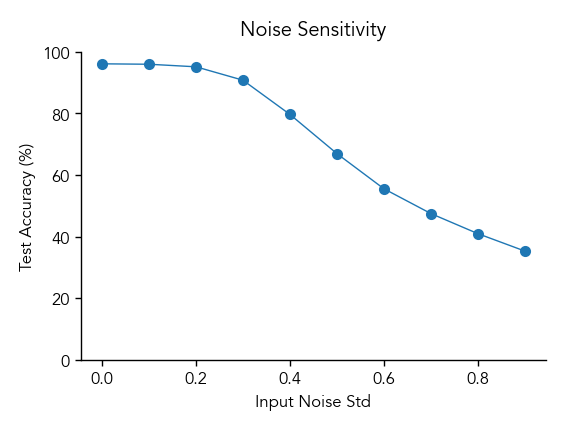

In [ ]:
plt.figure(figsize=(3,2))
plt.plot(np.arange(0, 1, 0.1), accuracy_list, marker='o', markersize=3)
plt.xlabel('Input Noise Std')
plt.ylabel('Test Accuracy (%)')
plt.title('Noise Sensitivity')
plt.ylim(0, 100)
plt.show()